<a href="https://colab.research.google.com/github/Shashi-kumar-g/machine-learning-26/blob/main/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [72]:
from sklearn import datasets
iris=datasets.load_iris()
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [73]:
data=pd.DataFrame({
    "sepal_length":iris.data[:,0],
    "sepal width":iris.data[:,1],
    "petal length":iris.data[:,2],
    "petal width":iris.data[:,3],
    "output":iris.target
})
data

,sepal_length,sepal width,petal length,petal width,output
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [74]:
#split data set in train -test split

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
#features and output splitting
X=data[['sepal_length','sepal width','petal length','petal width']]
y=data['output']

In [77]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.01,random_state=42)

In [78]:
#model define
from sklearn.ensemble import RandomForestClassifier

In [79]:
model=RandomForestClassifier(n_estimators=100)

In [80]:
model.fit(X_train,y_train)


RandomForestClassifier()

In [81]:
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy}")


Train Accuracy: 1.0


In [82]:
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 1.0


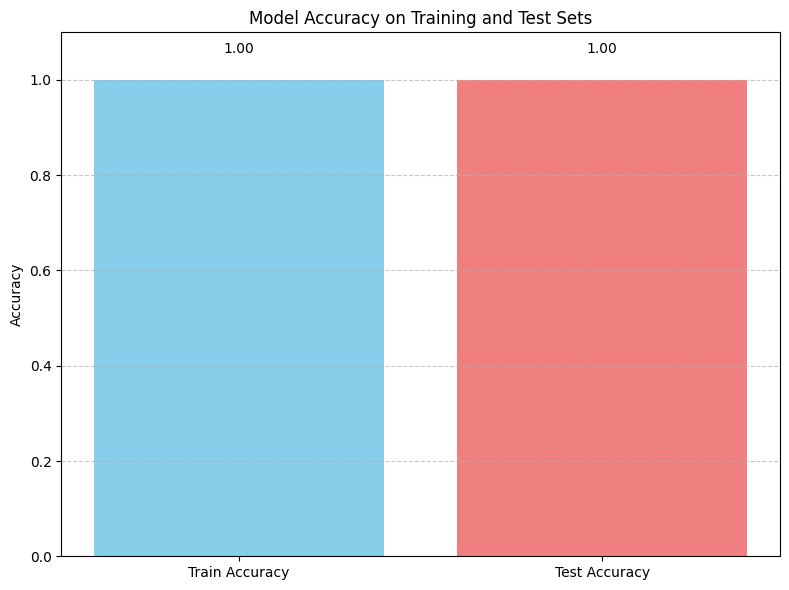

In [83]:


labels = ['Train Accuracy', 'Test Accuracy']
accuracies = [train_accuracy, test_accuracy]

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(labels, accuracies, color=['skyblue', 'lightcoral'])
ax.set_ylim(0, 1.1) # Set y-axis limit from 0 to 1.1 for better visualization
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy on Training and Test Sets')

for i, v in enumerate(accuracies):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

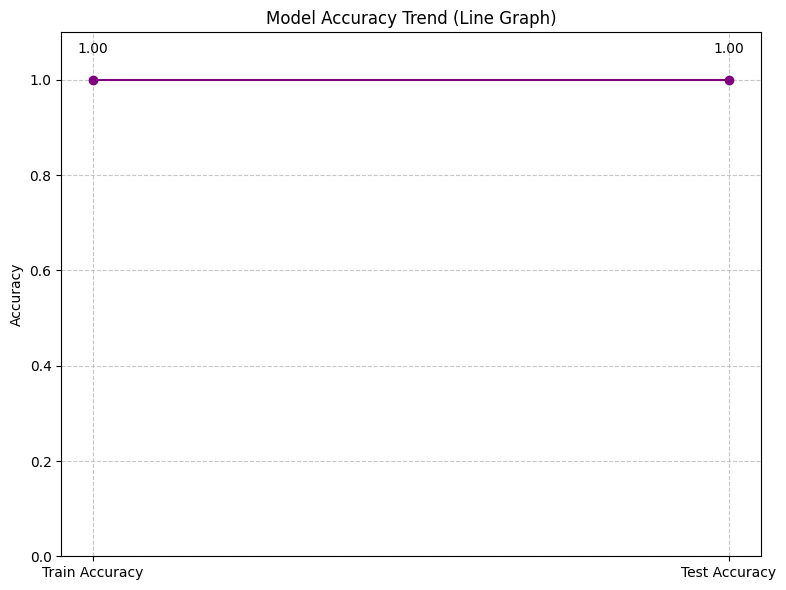

In [84]:
labels = ['Train Accuracy', 'Test Accuracy']
accuracies = [train_accuracy, test_accuracy]

fig_line, ax_line = plt.subplots(figsize=(8, 6))
ax_line.plot(labels, accuracies, marker='o', linestyle='-', color='purple')
ax_line.set_ylim(0, 1.1) # Set y-axis limit from 0 to 1.1
ax_line.set_ylabel('Accuracy')
ax_line.set_title('Model Accuracy Trend (Line Graph)')

for i, v in enumerate(accuracies):
    ax_line.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [85]:
#visulization
from sklearn.tree import export_graphviz
import pydot

In [93]:
import os

# Create the 'content' directory if it doesn't exist
os.makedirs('content', exist_ok=True)

tree=model.estimators_[10]
export_graphviz(tree,out_file="content/tree.dot",
                feature_names=iris.feature_names)
(graph,) = pydot.graph_from_dot_file("content/tree.dot")
graph.write_png("content/tree.png")